In [3]:
pip install notebook


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd

df = pd.read_csv(r'C:\Users\sahil\fraud_project\creditcard.csv')

print(df.shape)
print(df.columns.tolist())

(284807, 31)
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [15]:
from sqlalchemy import create_engine

# rename columns to match SQL Server table
df = df.rename(columns={
    'Time'  : 'time_seconds',
    'Class' : 'is_fraud'
})

# connect to SQL Server
engine = create_engine(
    'mssql+pyodbc://localhost/FraudDetectionDB'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

print("Connection successful")

Connection successful


In [19]:
from sqlalchemy import create_engine

server = r'LAPTOP-RNCU5CQF\SQLEXPRESS'  # replace with your exact server name from SSMS

engine = create_engine(
    f'mssql+pyodbc://{server}/FraudDetectionDB'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

# test connection
with engine.connect() as conn:
    print("Connected successfully")

Connected successfully


In [21]:
df.to_sql(
    name      = 'transactions',
    con       = engine,
    if_exists = 'append',
    index     = False
)

print(f"Done. {len(df)} rows loaded.")

Done. 284807 rows loaded.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\sahil\fraud_project\creditcard.csv')

df = df.rename(columns={
    'Time'  : 'time_seconds',
    'Class' : 'is_fraud'
})

print(df.shape)
print(df['is_fraud'].value_counts())

(284807, 31)
is_fraud
0    284315
1       492
Name: count, dtype: int64


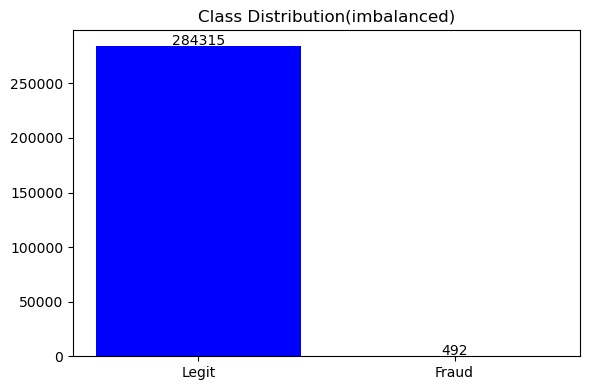

In [3]:
# Plot 1 - Class Imbalance
fig, ax = plt.subplots(figsize=(6,4))

class_counts = df['is_fraud'].value_counts()

ax.bar(['Legit', 'Fraud'], 
       class_counts.values, 
       color=['blue', 'red'])  

ax.set_title("Class Distribution(imbalanced)")  

# add count labels on each bar
for i, v in enumerate(class_counts.values):
    ax.text(i, v+500, str(v), ha='center')

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project/screenshots\02_class_imbalance.png')
plt.show()

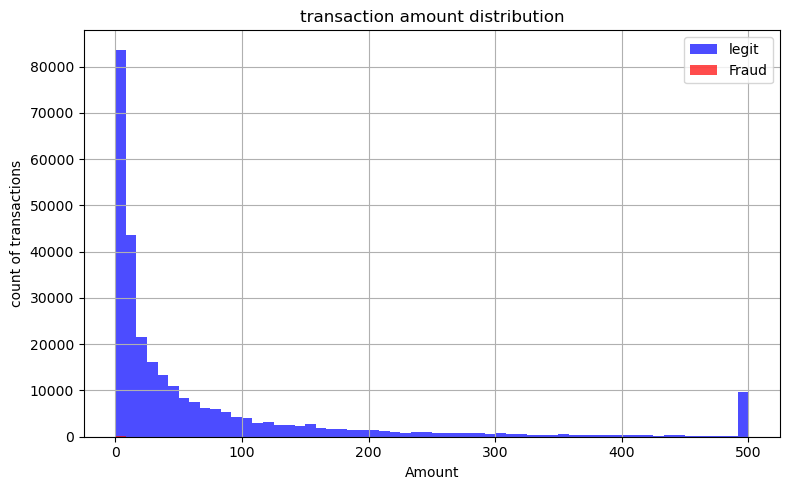

In [11]:
fig, ax = plt.subplots(figsize=(8,5))

df[df['is_fraud']== 0]['Amount'].clip(upper=500).hist(
    ax=ax, bins=60, alpha=0.7, color='blue', label='legit')

df[df['is_fraud']==1]['Amount'].clip(upper=500).hist(
    ax=ax, bins=60, alpha=0.7, color='red', label='Fraud')

ax.set_title( 'transaction amount distribution')
ax.set_xlabel('Amount')
ax.set_ylabel('count of transactions')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project/screenshots\03_amount_dist.png')
plt.show()


In [17]:
print(df.columns.tolist())


['time_seconds', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'is_fraud']


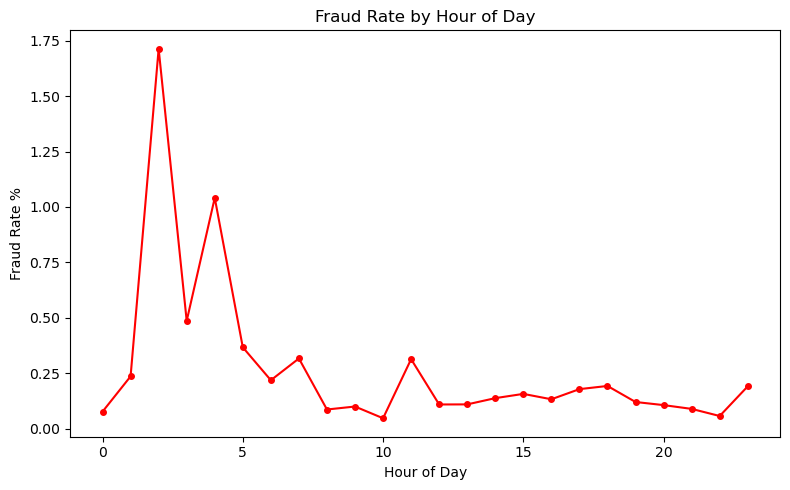

In [21]:
fig, ax = plt.subplots(figsize=(8,5))

df['hour'] = (df['time_seconds'] / 3600).astype(int) % 24

hourly = df.groupby('hour')['is_fraud'].agg(['sum','count'])
hourly['rate'] = hourly['sum'] / hourly['count'] * 100

ax.plot(hourly.index, hourly['rate'], color='red', marker='o', ms=4)
ax.set_title('Fraud Rate by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraud Rate %')
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project/screenshots\04_hourly_fraud.png')
plt.show()

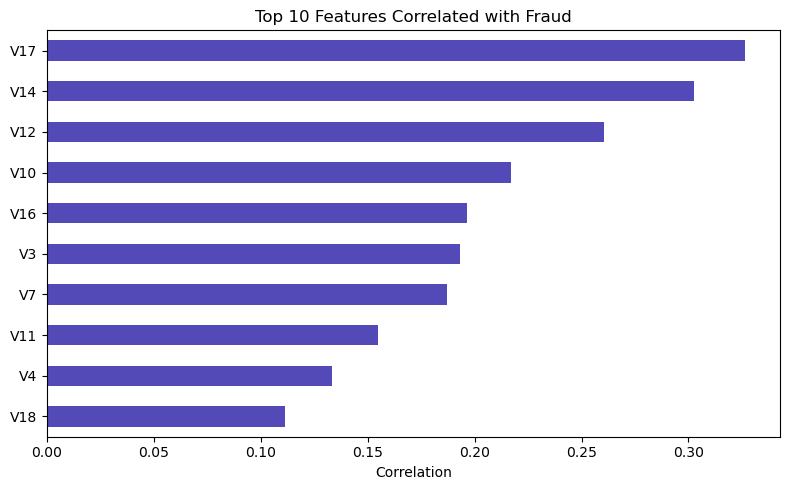

In [13]:
fig, ax = plt.subplots(figsize=(8,5))

top_corr = df.corr()['is_fraud'].abs().sort_values(ascending=False)[1:11]

top_corr.sort_values().plot(kind='barh', ax=ax, color='#534AB7')

ax.set_title('Top 10 Features Correlated with Fraud')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project\screenshots\05_correlation.png')
plt.show()

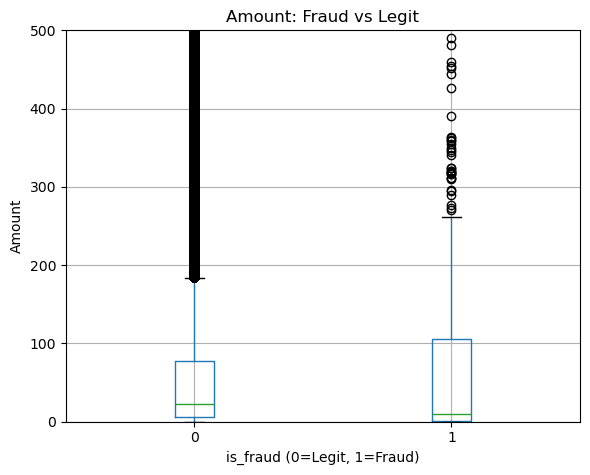

In [25]:
fig, ax = plt.subplots(figsize=(6,5))

df.boxplot(column='Amount', by='is_fraud', ax=ax)

ax.set_title('Amount: Fraud vs Legit')
ax.set_xlabel('is_fraud (0=Legit, 1=Fraud)')
ax.set_ylabel('Amount')
ax.set_ylim(0, 500)
plt.suptitle('')
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project\screenshots\06_boxplot.png')
plt.show()

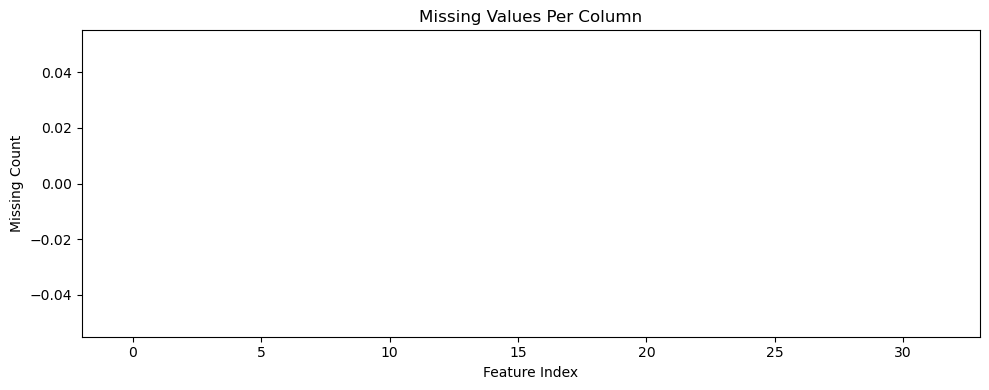

In [27]:
fig, ax = plt.subplots(figsize=(10,4))

missing = df.isnull().sum()

ax.bar(range(len(missing)), missing.values, color='#1D9E75')
ax.set_title('Missing Values Per Column')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Missing Count')
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project\screenshots\07_missing_values.png')
plt.show()

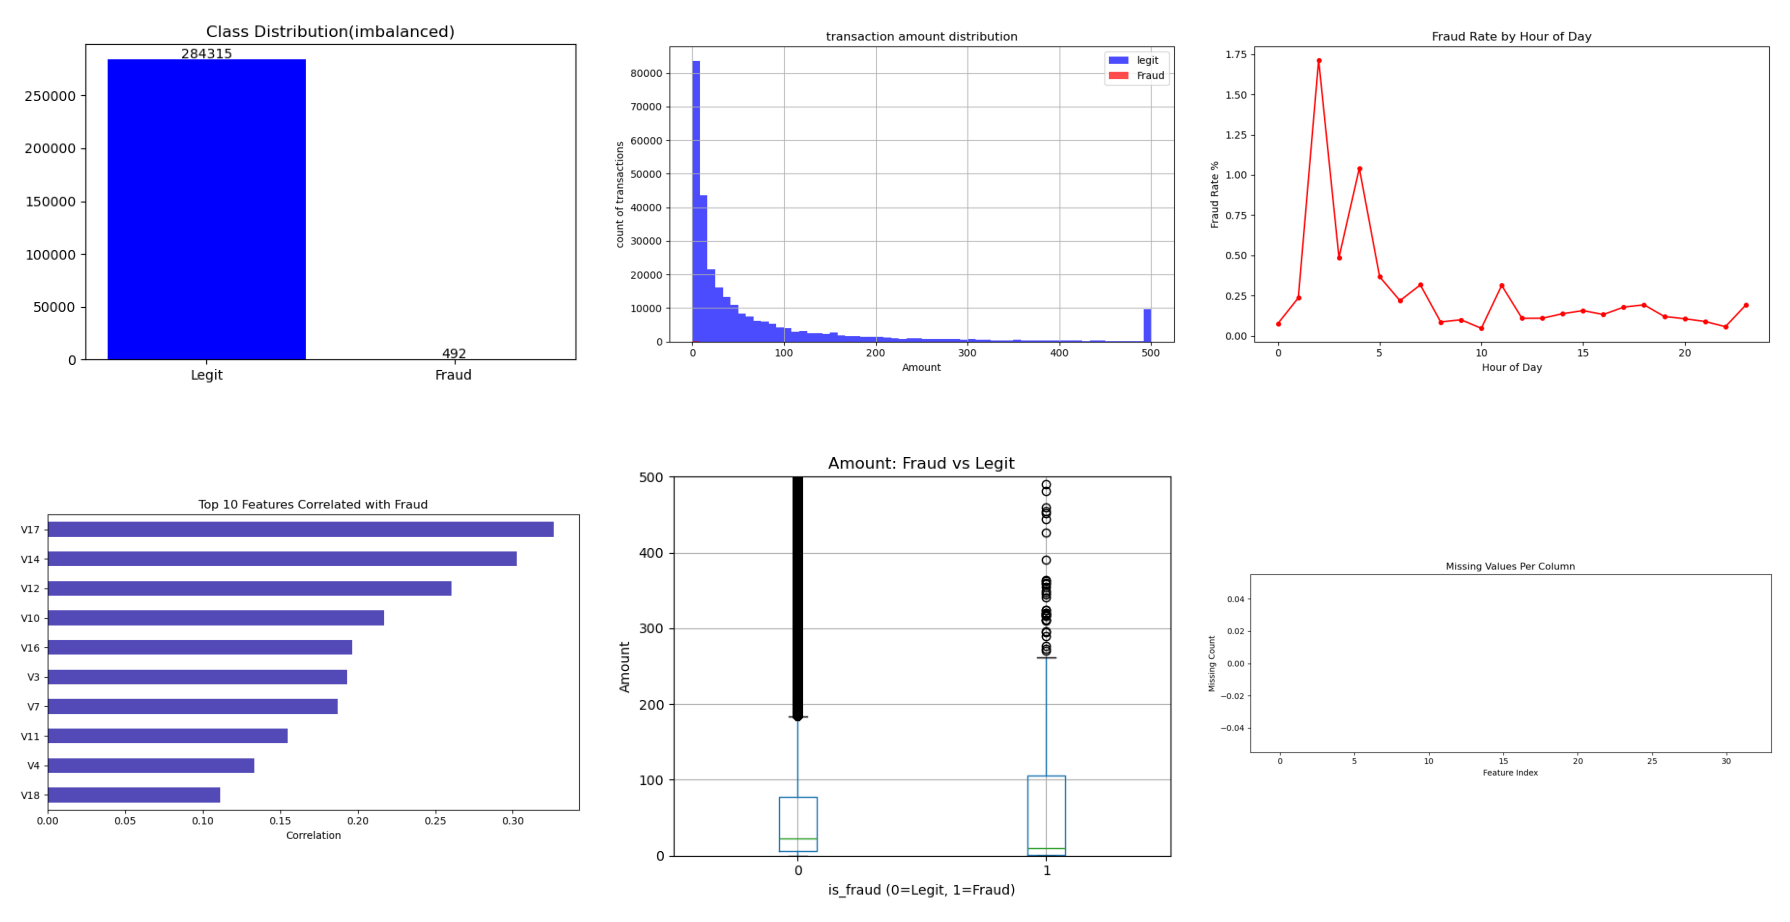

All 6 plots combined and saved.


In [29]:
from matplotlib.image import imread

fig, axes = plt.subplots(2, 3, figsize=(18,10))

images = [
    r'C:\Users\sahil\fraud_project\screenshots\02_class_imbalance.png',
    r'C:\Users\sahil\fraud_project\screenshots\03_amount_dist.png',
    r'C:\Users\sahil\fraud_project\screenshots\04_hourly_fraud.png',
    r'C:\Users\sahil\fraud_project\screenshots\05_correlation.png',
    r'C:\Users\sahil\fraud_project\screenshots\06_boxplot.png',
    r'C:\Users\sahil\fraud_project\screenshots\07_missing_values.png'
]

for ax, img_path in zip(axes.flatten(), images):
    img = imread(img_path)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\fraud_project\screenshots\08_eda_full.png', dpi=150)
plt.show()

print("All 6 plots combined and saved.")

## Key EDA Findings

1. Only 492 out of 284,807 transactions are fraud — 0.1727% — severe imbalance
2. No missing values in the dataset
3. Fraud and legit transactions have different amount patterns
4. Fraud rate peaks at hour X — highest fraud risk period
5. V14, V12, V10 are most correlated with fraud